# Demo 3: API Usage and Prompt Engineering for Health Data

This demo explores how to effectively use language model APIs for healthcare applications, focusing on prompt engineering techniques to improve reliability and reduce hallucination.

## Key Concepts
- Zero-shot, one-shot, and few-shot learning
- Schema-based prompting
- Chain-of-thought reasoning
- Error handling and validation
- Healthcare-specific considerations

The demo is designed to help health data science students understand how to:
1. Structure prompts for reliable medical text processing
2. Extract structured information from clinical notes
3. Generate medical reports and diagnoses
4. Handle errors and validate outputs

## Setup

First, we'll set up our environment and import necessary libraries. This includes:
1. Installing required packages
2. Setting up environment variables
3. Importing the OpenAI client

In [1]:
# Install required packages
%pip install -q openai python-dotenv pandas numpy matplotlib seaborn

%reset -f

# Import packages
import os
import json
from typing import List, Dict, Any
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from openai import OpenAI


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Getting Your API Key

To use the OpenAI API, you'll need an API key. This is a security measure to:
1. Track usage and billing
2. Apply rate limits
3. Monitor for abuse
4. Ensure responsible AI usage

For educational purposes, we'll use a smaller, more cost-effective model.

To use the OpenAI API, you'll need an API key:

1. Go to [platform.openai.com](https://platform.openai.com)
2. Sign up or log in to your account
3. Navigate to "API Keys" in the left sidebar
4. Click "Create new secret key"
5. Copy your API key and store it securely

For this demo, you can create a `.env` file in your working directory with: `OPENAI_API_KEY=your_api_key_here`

In [2]:
# Configure OpenAI API client
load_dotenv()  # Load API key from .env file
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Set model to use
MODEL_NAME = "gpt-4o-mini"  # Using a smaller, more cost-effective model
print(f"Using model: {MODEL_NAME}")

Using model: gpt-4o-mini


## Zero-Shot Learning

Zero-shot learning allows the model to perform tasks without any examples. This is useful when:
1. You don't have labeled examples
2. The task is relatively simple
3. You need quick results

In healthcare, zero-shot learning can be used for:
- Basic text classification
- Simple information extraction
- Initial screening of medical text

However, it may be less reliable for complex medical tasks.

In [3]:
def classify_medical_text(text: str, categories: List[str]) -> Dict[str, Any]:
    """
    Classify medical text into predefined categories using zero-shot learning.
    """
    prompt = f"""Classify the following medical text into one of these categories: {", ".join(categories)}.
    
Text: {text}

Provide the classification in JSON format with the following structure:
{{
    "category": "chosen_category",
    "confidence": confidence_score,
    "explanation": "brief explanation"
}}"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": "You are a medical text classification expert.",
                },
                {"role": "user", "content": prompt},
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3,
        )

        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {e}")
        return {"error": str(e)}


# Example usage
categories = ["Diagnosis", "Treatment", "Prognosis", "Medical History"]
text = "Patient presents with persistent cough and fever for 3 days. Chest X-ray shows right lower lobe infiltrate. Started on azithromycin 500mg daily."

print("Classifying medical text using zero-shot learning...")
result = classify_medical_text(text, categories)
print("\nClassification result:")
print(json.dumps(result, indent=2))

Classifying medical text using zero-shot learning...



Classification result:
{
  "category": "Treatment",
  "confidence": 0.95,
  "explanation": "The text describes the initiation of azithromycin, which is a treatment for the patient's condition indicated by the symptoms and chest X-ray findings."
}


## One-Shot Learning

One-shot learning provides a single example to guide the model. This is useful when:
1. You need consistent formatting
2. The task has specific requirements
3. You want to reduce hallucination

In healthcare, one-shot learning is valuable for:
- Generating structured medical reports
- Following specific documentation formats
- Maintaining consistency in medical records

In [4]:
def generate_medical_report(patient_data: Dict[str, Any]) -> str:
    """
    Generate a medical report using one-shot learning.
    """
    example = {
        "patient_id": "P12345",
        "age": 45,
        "symptoms": ["fever", "cough", "fatigue"],
        "vitals": {
            "temperature": 38.5,
            "heart_rate": 95,
            "blood_pressure": "120/80",
        },
        "diagnosis": "Acute bronchitis",
    }

    example_report = """MEDICAL REPORT
Patient ID: P12345
Age: 45

SYMPTOMS:
- Fever
- Cough
- Fatigue

VITAL SIGNS:
- Temperature: 38.5°C
- Heart Rate: 95 bpm
- Blood Pressure: 120/80 mmHg

DIAGNOSIS:
Acute bronchitis

RECOMMENDATIONS:
1. Rest and adequate hydration
2. Over-the-counter antipyretics for fever
3. Follow-up in 1 week if symptoms persist"""

    prompt = f"""Generate a medical report following this exact format:

{example_report}

Now generate a report for this patient data:
{json.dumps(patient_data, indent=2)}"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": "You are a medical report generation expert.",
                },
                {"role": "user", "content": prompt},
            ],
            temperature=0.3,
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"API Error: {str(e)}")
        return f"Error generating report: {str(e)}"


# Example usage
patient_data = {
    "patient_id": "P67890",
    "age": 62,
    "symptoms": ["chest pain", "shortness of breath", "sweating"],
    "vitals": {
        "temperature": 37.2,
        "heart_rate": 110,
        "blood_pressure": "145/90",
    },
    "diagnosis": "Suspected angina",
}

print("Generating medical report using one-shot learning...")
report = generate_medical_report(patient_data)
print("\nGenerated report:")
print(report)

Generating medical report using one-shot learning...



Generated report:
MEDICAL REPORT  
Patient ID: P67890  
Age: 62  

SYMPTOMS:  
- Chest pain  
- Shortness of breath  
- Sweating  

VITAL SIGNS:  
- Temperature: 37.2°C  
- Heart Rate: 110 bpm  
- Blood Pressure: 145/90 mmHg  

DIAGNOSIS:  
Suspected angina  

RECOMMENDATIONS:  
1. Immediate evaluation by a cardiologist  
2. Avoid strenuous activities until further assessment  
3. Consider nitroglycerin for chest pain as prescribed  
4. Follow-up appointment within 48 hours or sooner if symptoms worsen  


## Few-Shot Learning

Few-shot learning provides multiple examples to help the model understand patterns. This is useful when:
1. The task is complex
2. You need high accuracy
3. You want to capture nuanced relationships

In healthcare, few-shot learning is valuable for:
- Medical coding
- Complex diagnosis
- Treatment planning
- Risk assessment

In [5]:
def assign_icd_codes(
    clinical_note: str, num_examples: int = 3
) -> List[Dict[str, Any]]:
    """
    Assign ICD-10 codes to a clinical note using few-shot learning.
    """
    examples = [
        {
            "note": "Patient presents with type 2 diabetes mellitus, uncontrolled. HbA1c 9.2%. Also reports diabetic retinopathy.",
            "codes": [
                {
                    "code": "E11.9",
                    "description": "Type 2 diabetes mellitus without complications",
                },
                {
                    "code": "E11.3",
                    "description": "Type 2 diabetes mellitus with ophthalmic complications",
                },
            ],
        },
        {
            "note": "Acute appendicitis with localized peritonitis. Patient taken to OR for appendectomy.",
            "codes": [
                {
                    "code": "K35.2",
                    "description": "Acute appendicitis with localized peritonitis",
                },
                {"code": "47.01", "description": "Laparoscopic appendectomy"},
            ],
        },
        {
            "note": "Hypertensive heart disease with heart failure. Patient on ACE inhibitor and diuretic.",
            "codes": [
                {
                    "code": "I11.0",
                    "description": "Hypertensive heart disease with heart failure",
                },
                {"code": "I50.9", "description": "Heart failure, unspecified"},
            ],
        },
    ]

    # Select examples
    selected_examples = examples[:num_examples]

    prompt = f"""Assign ICD-10 codes to the following clinical notes. Here are some examples:

{json.dumps(selected_examples, indent=2)}

Now assign codes to this note:
{clinical_note}

Provide the codes in JSON format with the following structure:
[
    {{
        "code": "ICD-10 code",
        "description": "code description"
    }}
]"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": "You are a medical coding expert.",
                },
                {"role": "user", "content": prompt},
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3,
        )

        # The response will be a JSON object with a single property containing the array
        result = json.loads(response.choices[0].message.content)

        # If the result is a dictionary with a single key containing an array, extract the array
        if (
            isinstance(result, dict)
            and len(result) == 1
            and isinstance(list(result.values())[0], list)
        ):
            return list(result.values())[0]

        # If the result is already an array, return it
        if isinstance(result, list):
            return result

        # Otherwise, wrap the result in an array
        return [{"codes": result}]
    except Exception as e:
        print(f"API Error: {str(e)}")
        return [{"error": str(e)}]


# Example usage
note = "Patient with chronic obstructive pulmonary disease, severe. Presents with acute exacerbation. Started on prednisone and antibiotics."
print("Assigning ICD-10 codes using few-shot learning...")
codes = assign_icd_codes(note)
print("\nAssigned codes:")
print(json.dumps(codes, indent=2))

Assigning ICD-10 codes using few-shot learning...



Assigned codes:
[
  {
    "code": "J44.1",
    "description": "Chronic obstructive pulmonary disease with acute exacerbation"
  },
  {
    "code": "J43.9",
    "description": "Emphysema, unspecified"
  }
]


## Comparing Effectiveness of Shot Learning Approaches

This section demonstrates how different shot learning approaches affect model performance. We'll compare:
1. Zero-shot: No examples provided
2. One-shot: Single example provided
3. Few-shot: Multiple examples provided

This helps us understand:
- When to use each approach
- The trade-offs between approaches
- How to optimize for different healthcare tasks

Making API calls to compare different shot learning approaches...

Zero-Shot Learning:


API Response:
{
  "diagnosis": "Community-acquired pneumonia",
  "confidence": 0.7,
  "reasoning": "The patient presents with a persistent cough and fever, which are common symptoms of pneumonia. The chest X-ray shows a right lower lobe infiltrate, further supporting the diagnosis of pneumonia. The initiation of azithromycin suggests a bacterial cause, which is typical for community-acquired pneumonia. However, without further information on the patient's history or response to treatment, the confidence score is moderate."
}

One-Shot Learning:


API Response:
{
  "diagnosis": "Community-acquired pneumonia",
  "confidence": 0.85,
  "reasoning": "The patient presents with fever and cough, and the chest X-ray shows right lower lobe infiltrate, which is consistent with pneumonia. The initiation of azithromycin suggests a clinical suspicion of bacterial infection, although the absence of elevated WBC and specific sputum characteristics lowers the confidence slightly."
}

Few-Shot Learning:


API Response:
{
  "diagnosis": {
    "diagnosis": "Community-acquired pneumonia",
    "confidence": 0.9,
    "reasoning": "The patient's persistent cough, fever, and chest X-ray findings of right lower lobe infiltrate are indicative of pneumonia. The initiation of azithromycin suggests a bacterial etiology, which aligns with the diagnosis of community-acquired pneumonia."
  }
}

Raw confidence scores from API responses:
Zero-Shot: 0.7
One-Shot: 0.85
Few-Shot: 0.9


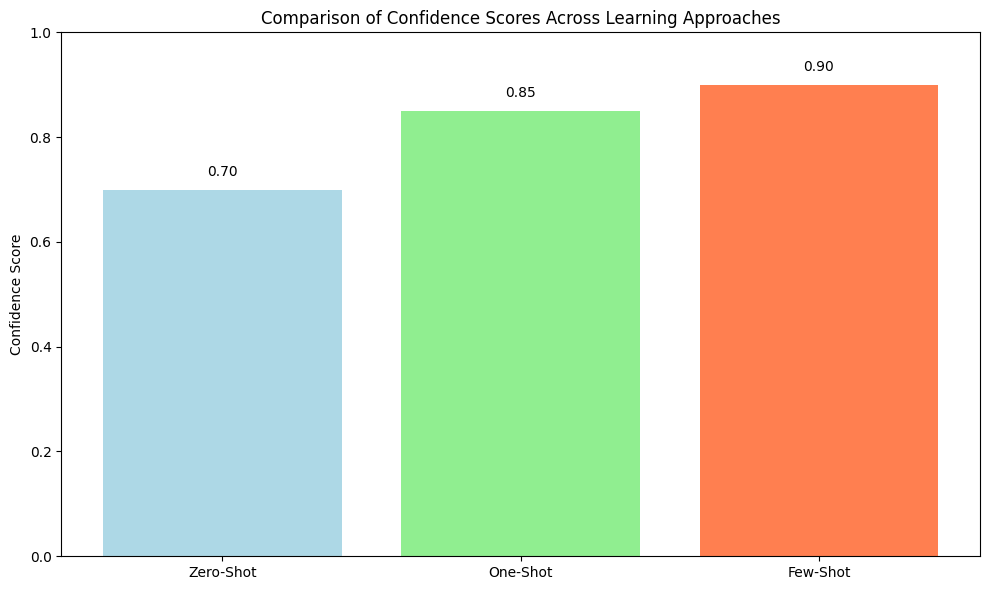


Comparison Table:
    Approach                     Diagnosis  Confidence Detail Level  \
0  Zero-Shot  Community-acquired pneumonia        0.70          Low   
1   One-Shot  Community-acquired pneumonia        0.85       Medium   
2   Few-Shot  Community-acquired pneumonia        0.90         High   

   Reasoning Length  
0               427  
1               323  
2               250  


In [6]:
# Helper functions for processing API responses
def get_confidence(result: Dict[str, Any]) -> float:
    """Extract confidence score from API response."""
    if "error" in result:
        return 0.0
    if isinstance(result.get("diagnosis"), dict):
        return result["diagnosis"].get("confidence", 0.0)
    return result.get("confidence", 0.0)


def get_diagnosis(result: Dict[str, Any]) -> str:
    """Extract diagnosis from API response."""
    if "error" in result:
        return "Error"
    if isinstance(result.get("diagnosis"), dict):
        return result["diagnosis"].get("diagnosis", "Unknown")
    return result.get("diagnosis", "Unknown")


def get_reasoning_length(result: Dict[str, Any]) -> int:
    """Get length of reasoning from API response."""
    if "error" in result:
        return 0
    if isinstance(result.get("diagnosis"), dict):
        return len(result["diagnosis"].get("reasoning", ""))
    return len(result.get("reasoning", ""))


def diagnose_with_shot_learning(
    clinical_case: str, approach: str
) -> Dict[str, Any]:
    """
    Diagnose a clinical case using different shot learning approaches.

    Parameters:
    - clinical_case: The clinical case to diagnose
    - approach: One of "zero-shot", "one-shot", or "few-shot"
    """
    if approach == "zero-shot":
        # Zero-shot approach: No examples provided
        prompt = f"""Diagnose the following clinical case:

Clinical case: {clinical_case}

Provide your diagnosis in JSON format with the following structure:
{{
    "diagnosis": "your diagnosis",
    "confidence": confidence_score (between 0 and 1),
    "reasoning": "brief explanation of your reasoning"
}}

Note: For zero-shot learning, be conservative with confidence scores since no examples are provided."""

        system_role = "You are a medical diagnostician. Be conservative with confidence scores when no examples are provided."

    elif approach == "one-shot":
        # One-shot approach: One example provided
        example_case = """Patient presents with fever (39°C), productive cough with yellow sputum for 5 days, and shortness of breath. Physical exam reveals crackles in the left lower lobe. WBC is 14,000. Chest X-ray shows left lower lobe consolidation."""

        example_diagnosis = {
            "diagnosis": "Community-acquired pneumonia",
            "confidence": 0.92,
            "reasoning": "The combination of fever, productive cough, elevated WBC, and radiographic evidence of consolidation is highly suggestive of bacterial pneumonia.",
        }

        prompt = f"""Diagnose the following clinical case based on the example:

Example case: {example_case}

Example diagnosis:
{json.dumps(example_diagnosis, indent=2)}

Now diagnose this case:
{clinical_case}

Provide your diagnosis in the same JSON format as the example.
Note: Adjust confidence based on how closely the case matches the example pattern."""

        system_role = "You are a medical diagnostician. Adjust confidence based on pattern matching with the example."

    elif approach == "few-shot":
        # Few-shot approach: Multiple examples provided
        examples = [
            {
                "case": "Patient presents with fever (39°C), productive cough with yellow sputum for 5 days, and shortness of breath. Physical exam reveals crackles in the left lower lobe. WBC is 14,000. Chest X-ray shows left lower lobe consolidation.",
                "diagnosis": {
                    "diagnosis": "Community-acquired pneumonia",
                    "confidence": 0.95,
                    "reasoning": "The combination of fever, productive cough, elevated WBC, and radiographic evidence of consolidation is highly suggestive of bacterial pneumonia.",
                },
            },
            {
                "case": "Patient presents with sudden onset chest pain that radiates to the left arm, associated with nausea and diaphoresis. ECG shows ST elevation in leads II, III, and aVF. Troponin is elevated.",
                "diagnosis": {
                    "diagnosis": "Acute inferior myocardial infarction",
                    "confidence": 0.98,
                    "reasoning": "The clinical presentation, ECG findings, and elevated troponin are diagnostic of an acute MI involving the inferior wall of the heart.",
                },
            },
            {
                "case": "Patient presents with right upper quadrant pain, fever, and jaundice. Labs show elevated WBC, total bilirubin, and alkaline phosphatase. Ultrasound shows gallstones and dilated common bile duct.",
                "diagnosis": {
                    "diagnosis": "Acute cholangitis",
                    "confidence": 0.93,
                    "reasoning": "The triad of RUQ pain, fever, and jaundice (Charcot's triad) along with imaging findings of biliary obstruction are consistent with acute cholangitis.",
                },
            },
        ]

        prompt = f"""Diagnose the following clinical case based on these examples:

Examples:
{json.dumps(examples, indent=2)}

Now diagnose this case:
{clinical_case}

Provide your diagnosis in the same JSON format as the examples.
Note: Use higher confidence scores when the case closely matches multiple examples, and lower scores when there are significant differences."""

        system_role = "You are a medical diagnostician with expertise in pattern recognition. Use higher confidence scores when the case closely matches multiple examples."

    else:
        raise ValueError(
            f"Unknown approach: {approach}. Must be one of 'zero-shot', 'one-shot', or 'few-shot'."
        )

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_role},
                {"role": "user", "content": prompt},
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3,
        )

        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {str(e)}")
        return {
            "error": str(e),
            "diagnosis": "Error",
            "confidence": 0,
            "reasoning": "",
        }


# Example clinical case
clinical_case = "Patient presents with persistent cough and fever for 3 days. Chest X-ray shows right lower lobe infiltrate. Started on azithromycin 500mg daily."

print("Making API calls to compare different shot learning approaches...")
print("\nZero-Shot Learning:")
try:
    zero_shot_result = diagnose_with_shot_learning(clinical_case, "zero-shot")
    print("API Response:")
    print(json.dumps(zero_shot_result, indent=2))
except Exception as e:
    print(f"Error in zero-shot API call: {str(e)}")
    zero_shot_result = {
        "error": str(e),
        "diagnosis": "Error",
        "confidence": 0,
        "reasoning": "",
    }

print("\nOne-Shot Learning:")
try:
    one_shot_result = diagnose_with_shot_learning(clinical_case, "one-shot")
    print("API Response:")
    print(json.dumps(one_shot_result, indent=2))
except Exception as e:
    print(f"Error in one-shot API call: {str(e)}")
    one_shot_result = {
        "error": str(e),
        "diagnosis": "Error",
        "confidence": 0,
        "reasoning": "",
    }

print("\nFew-Shot Learning:")
try:
    few_shot_result = diagnose_with_shot_learning(clinical_case, "few-shot")
    print("API Response:")
    print(json.dumps(few_shot_result, indent=2))
except Exception as e:
    print(f"Error in few-shot API call: {str(e)}")
    few_shot_result = {
        "error": str(e),
        "diagnosis": "Error",
        "confidence": 0,
        "reasoning": "",
    }

# Print raw results for debugging
print("\nRaw confidence scores from API responses:")
for approach, result in [
    ("Zero-Shot", zero_shot_result),
    ("One-Shot", one_shot_result),
    ("Few-Shot", few_shot_result),
]:
    confidence = get_confidence(result)
    print(f"{approach}: {confidence}")

# Visualize confidence scores
approaches = ["Zero-Shot", "One-Shot", "Few-Shot"]
confidence_scores = [
    get_confidence(zero_shot_result),
    get_confidence(one_shot_result),
    get_confidence(few_shot_result),
]

plt.figure(figsize=(10, 6))
bars = plt.bar(
    approaches, confidence_scores, color=["lightblue", "lightgreen", "coral"]
)
plt.ylim(0, 1.0)
plt.ylabel("Confidence Score")
plt.title("Comparison of Confidence Scores Across Learning Approaches")

# Add the values on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

# Create a comparison table
comparison_data = {
    "Approach": approaches,
    "Diagnosis": [
        get_diagnosis(zero_shot_result),
        get_diagnosis(one_shot_result),
        get_diagnosis(few_shot_result),
    ],
    "Confidence": confidence_scores,
    "Detail Level": ["Low", "Medium", "High"],
    "Reasoning Length": [
        get_reasoning_length(zero_shot_result),
        get_reasoning_length(one_shot_result),
        get_reasoning_length(few_shot_result),
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print("\nComparison Table:")
print(comparison_df)

## Schema-Based Prompting

Schema-based prompting is a powerful technique for extracting structured information from unstructured medical text. This is useful for:
1. Converting clinical notes to structured data
2. Extracting specific medical entities
3. Standardizing medical information

The schema defines the expected structure of the output, helping to:
- Ensure consistency
- Reduce hallucination
- Improve reliability

In [7]:
def extract_structured_data(
    text: str, schema: Dict[str, Any]
) -> Dict[str, Any]:
    """
    Extract structured data from medical text using schema-based prompting.
    """
    prompt = f"""Extract information from the following medical text according to this schema:
{json.dumps(schema, indent=2)}

Text: {text}

Provide the extracted data in JSON format matching the schema exactly.
If a field is not found in the text, use null as the value."""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": "You are a medical information extraction expert.",
                },
                {"role": "user", "content": prompt},
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3,
        )

        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {str(e)}")
        return {"error": str(e)}


# Example usage
schema = {
    "patient_demographics": {
        "age": "number",
        "gender": "string",
        "race": "string",
    },
    "vital_signs": {
        "temperature": "number",
        "heart_rate": "number",
        "blood_pressure": "string",
        "oxygen_saturation": "number",
    },
    "medications": {"current_meds": ["string"], "allergies": ["string"]},
}

text = """45-year-old African American male presents to ED. 
Vitals: T 38.2, HR 110, BP 145/90, O2 sat 96% on room air.
Current medications: Lisinopril 10mg daily, Metformin 1000mg BID.
Allergies: Penicillin, Sulfa drugs."""

print("Extracting structured data using schema-based prompting...")
structured_data = extract_structured_data(text, schema)
print("\nExtracted data:")
print(json.dumps(structured_data, indent=2))

Extracting structured data using schema-based prompting...



Extracted data:
{
  "patient_demographics": {
    "age": 45,
    "gender": "male",
    "race": "African American"
  },
  "vital_signs": {
    "temperature": 38.2,
    "heart_rate": 110,
    "blood_pressure": "145/90",
    "oxygen_saturation": 96
  },
  "medications": {
    "current_meds": [
      "Lisinopril 10mg daily",
      "Metformin 1000mg BID"
    ],
    "allergies": [
      "Penicillin",
      "Sulfa drugs"
    ]
  }
}


## Chain-of-Thought Prompting

Chain-of-thought prompting guides the model through a step-by-step reasoning process. This is valuable for:
1. Complex medical diagnosis
2. Treatment planning
3. Risk assessment
4. Clinical decision support

The step-by-step approach helps to:
- Make the reasoning process transparent
- Reduce errors
- Build trust with healthcare professionals

In [8]:
def analyze_medical_case(case: str) -> Dict[str, Any]:
    """
    Analyze a medical case using chain-of-thought prompting.
    """
    prompt = f"""Analyze this medical case step by step:

{case}

Follow these steps:
1. List the key symptoms and findings
2. Identify potential differential diagnoses
3. Explain your reasoning for each diagnosis
4. Recommend next steps for diagnosis
5. Suggest initial treatment approach

Provide your analysis in JSON format with the following structure:
{{
    "symptoms": ["list of symptoms"],
    "findings": ["list of findings"],
    "differential_diagnoses": [
        {{
            "diagnosis": "diagnosis name",
            "probability": "high/medium/low",
            "reasoning": "explanation"
        }}
    ],
    "next_steps": ["list of recommended steps"],
    "treatment": ["list of treatment suggestions"]
}}"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": "You are a medical case analysis expert.",
                },
                {"role": "user", "content": prompt},
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3,
        )

        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {str(e)}")
        return {"error": str(e)}


# Example usage
case = """A 35-year-old woman presents with 3 days of right upper quadrant pain, 
fever to 38.5°C, and nausea. Physical exam shows right upper quadrant tenderness 
and positive Murphy's sign. WBC is 15,000 with 85% neutrophils. 
Ultrasound shows gallbladder wall thickening and pericholecystic fluid."""

print("Analyzing medical case using chain-of-thought prompting...")
analysis = analyze_medical_case(case)
print("\nAnalysis result:")
print(json.dumps(analysis, indent=2))

Analyzing medical case using chain-of-thought prompting...



Analysis result:
{
  "symptoms": [
    "right upper quadrant pain",
    "fever to 38.5\u00b0C",
    "nausea"
  ],
  "findings": [
    "right upper quadrant tenderness",
    "positive Murphy's sign",
    "WBC count of 15,000 with 85% neutrophils",
    "gallbladder wall thickening on ultrasound",
    "pericholecystic fluid on ultrasound"
  ],
  "differential_diagnoses": [
    {
      "diagnosis": "Acute Cholecystitis",
      "probability": "high",
      "reasoning": "The presence of right upper quadrant pain, fever, nausea, and ultrasound findings of gallbladder wall thickening and pericholecystic fluid strongly suggest acute cholecystitis, which is inflammation of the gallbladder typically due to obstruction of the cystic duct."
    },
    {
      "diagnosis": "Biliary Colic",
      "probability": "medium",
      "reasoning": "While biliary colic can cause similar symptoms, it typically does not present with fever or significant leukocytosis, and the ultrasound findings of wall thicken

## Error Handling and Validation

Error handling and validation are crucial for healthcare applications. This section demonstrates:
1. How to handle API errors gracefully
2. How to validate extracted information
3. How to ensure data quality
4. How to maintain reliability

This is essential for:
- Patient safety
- Clinical reliability
- System robustness

In [9]:
def extract_medical_entities(text: str) -> Dict[str, Any]:
    """
    Extract medical entities from text with error handling.
    """
    prompt = f"""Extract all medical entities from the following text:
    
Text: {text}

Categorize them into:
- Conditions
- Medications
- Procedures
- Lab tests
- Vital signs

Return the results in JSON format with the following structure:
{{
    "conditions": ["list of conditions"],
    "medications": ["list of medications"],
    "procedures": ["list of procedures"],
    "lab_tests": ["list of lab tests"],
    "vital_signs": ["list of vital signs"]
}}"""

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": "You are a medical NLP expert."},
                {"role": "user", "content": prompt},
            ],
            response_format={"type": "json_object"},  # Request JSON response
            temperature=0.3,
        )

        return json.loads(response.choices[0].message.content)
    except Exception as e:
        print(f"API Error: {str(e)}")
        return {"error": str(e)}


# Example usage
sample_text = "Patient with history of hypertension and type 2 diabetes. Recent CBC shows elevated WBC. Taking lisinopril and metformin."
print("Extracting medical entities with error handling...")
entities = extract_medical_entities(sample_text)
print("\nExtracted entities:")
print(json.dumps(entities, indent=2))

Extracting medical entities with error handling...



Extracted entities:
{
  "conditions": [
    "hypertension",
    "type 2 diabetes"
  ],
  "medications": [
    "lisinopril",
    "metformin"
  ],
  "procedures": [],
  "lab_tests": [
    "CBC"
  ],
  "vital_signs": []
}


## Key Takeaways

This demo has covered several important concepts for using language models in healthcare:

1. **Prompt Engineering Techniques**
   - **Zero-shot learning** requires no examples but may produce less specific results. It's ideal for simple, common tasks where examples aren't available.
   - **One-shot learning** provides a single example that significantly improves output quality with minimal overhead. This approach is very efficient for formatting tasks.
   - **Few-shot learning** uses multiple examples to help the model recognize patterns, producing more detailed and confident results. Best for complex tasks where accuracy is critical.
   - **Chain-of-thought prompting** guides the model through step-by-step reasoning, mimicking clinical decision-making processes and ensuring thorough analysis.
   - **Schema-based prompting** extracts structured information from unstructured text, essential for converting clinical notes into analyzable data.

2. **Structured Output**
   - JSON schema for consistent formatting ensures interoperability with other systems
   - Clear instructions for data extraction improve reliability and completeness
   - Validation of extracted information prevents propagation of errors
   - Structured outputs facilitate downstream processing and analysis

3. **Healthcare-Specific Considerations**
   - Medical terminology accuracy is critical for clinical applications
   - Clinical reasoning transparency helps build trust with healthcare professionals
   - Ethical and privacy concerns must be addressed when handling patient data
   - Reliability and robustness are essential when systems may impact patient care

4. **Best Practices**
   - Clear and specific prompts reduce ambiguity and improve consistency
   - Appropriate temperature settings balance creativity and determinism
   - Error handling and validation ensure graceful degradation when issues occur
   - Documentation of prompt templates facilitates maintenance and knowledge sharing
   - Testing across diverse cases helps identify edge cases and potential biases